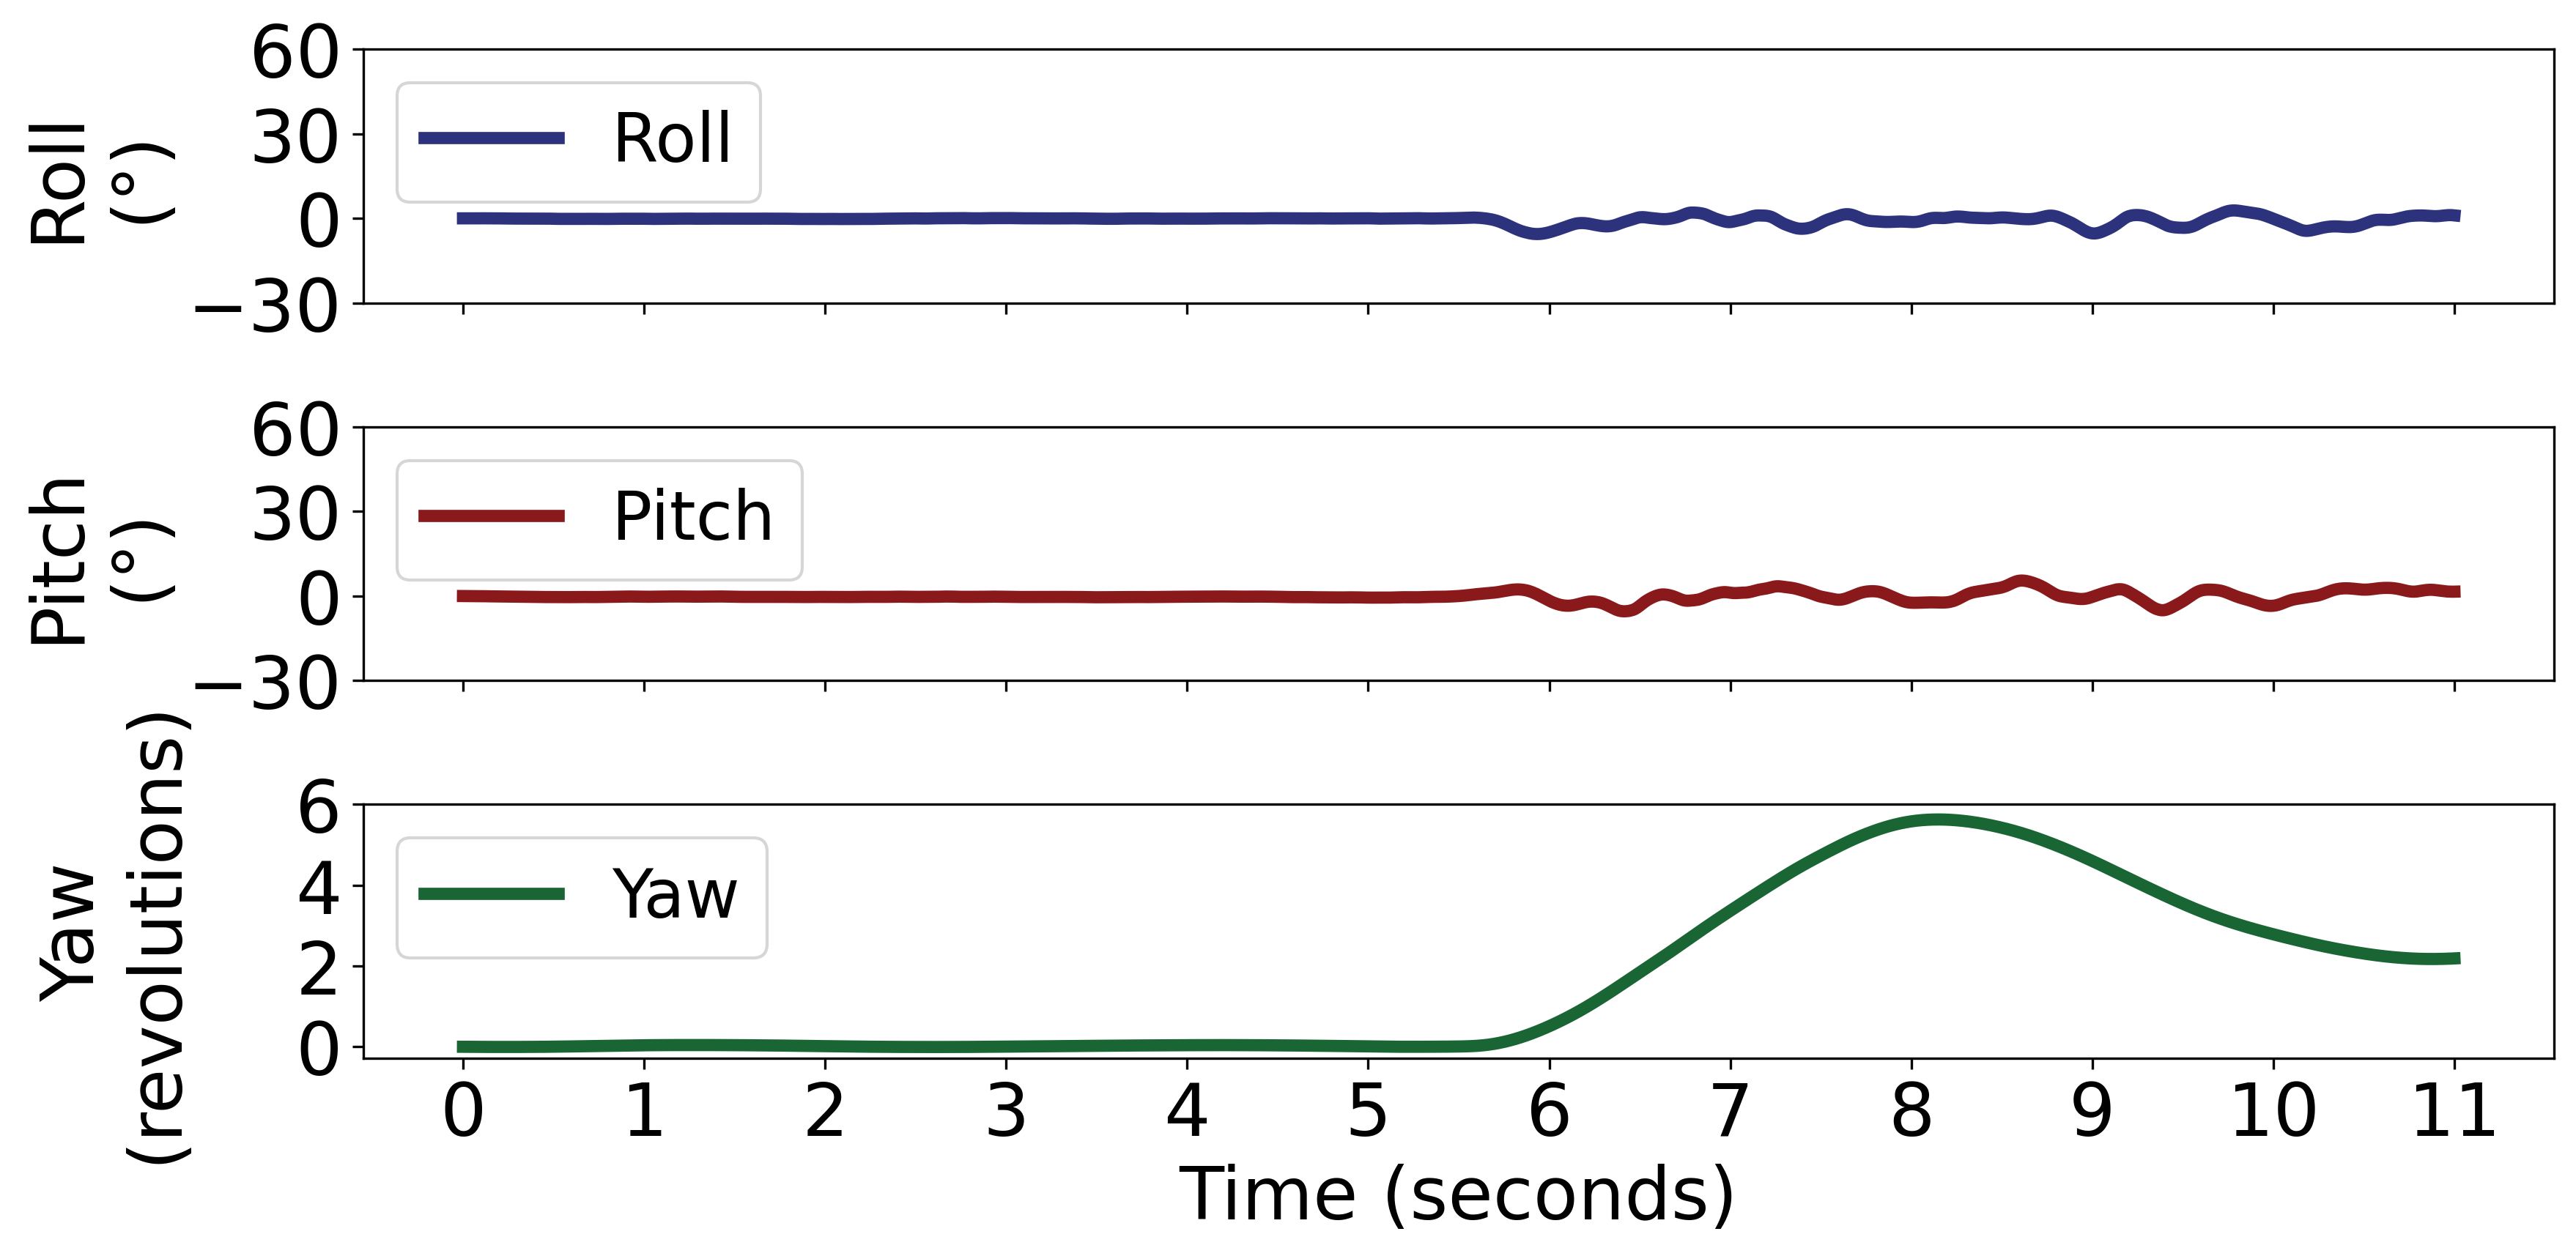

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import math
plt.rcParams.update({'font.size': 16})

# === Global Constants ===
G_PROMINENCE = 0.05
G_DISTANCE = 100
G_AXIS = 'Roll'
FPS = 240
data_start = 9 * FPS  # e.g., data_start = 10 * FPS for a 10 second delay
data_end = 11 # time in seconds
G_VIEW = data_end * FPS

# === Y-Axis Displacement Variables ===
roll_disp = 0      # Displacement for Roll (in degrees)
pitch_disp = 0     # Displacement for Pitch (in degrees)
yaw_disp = 0       # Displacement for Yaw (in degrees)

# === Helper Functions ===
def toDegrees(rad):
    return rad * 180 / math.pi

def euler_from_quaternion(x, y, z, w):
    """
    Convert a quaternion (x, y, z, w) to Euler angles (roll, pitch, yaw)
    using the Tait-Bryan angles (rotation order ZYX). The angles are returned in degrees.
    """
    # Compute Roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)

    # Compute Pitch (y-axis rotation)
    sinp = 2.0 * (w * y - z * x)
    # Use np.clip for numerical stability
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = math.asin(sinp)

    # Compute Yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)

    return math.degrees(roll) * -1, math.degrees(pitch), math.degrees(yaw)

def smooth_signal(signal, window_length=75, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

def process_euler(df, custom_start=None):
    # Convert quaternion columns to Euler angles.
    euler_angles = df.apply(
        lambda row: euler_from_quaternion(
            row['X - rotation'], row['Y - rotation'], row['Z - rotation'], row['W - rotation']
        ),
        axis=1
    )
    euler_df = pd.DataFrame(euler_angles.tolist(), columns=['Roll', 'Pitch', 'Yaw'])

    # Smooth each Euler angle signal.
    for axis in ['Roll', 'Pitch']: # , 'Yaw'
        euler_df[axis] = smooth_signal(euler_df[axis])

    # Auto-detect starting index using peaks in the Roll signal.
    peak_indices, _ = find_peaks(euler_df[G_AXIS], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)
    start_peak_idx = None
    for i in range(1, len(peak_indices)):
        if abs(euler_df[G_AXIS].iloc[peak_indices[i]] - euler_df[G_AXIS].iloc[peak_indices[i - 1]]) > 50:
            start_peak_idx = peak_indices[i - 1]
            break

    if custom_start is not None:
        start = custom_start
    else:
        start = max((start_peak_idx if start_peak_idx is not None else 0), 5)
    end = start + G_VIEW
    return euler_df.iloc[start - 5:end].reset_index(drop=True)

def trim_by_degree_change(euler_df, threshold=10):
    roll = euler_df['Roll'].values
    for i in range(1, len(roll)):
        if abs(roll[i] - roll[i - 1]) < threshold:
            return euler_df.iloc[i:].reset_index(drop=True)
    return euler_df

# === Load and Process a Single Dataset ===
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTUwR0rogGjykYjx1PKppVcptLPQT8v297iBpoLceHiJSkKruoVBbYy3whZahx7L0mvKYdo6XXHBsWd/pub?gid=1119363636&single=true&output=csv"
df = pd.read_csv(url)

# Process the Euler angles.
euler_df = process_euler(df, custom_start=data_start)
euler_df_trimmed = euler_df  # or use trim_by_degree_change(euler_df) if desired

# Unwrap the yaw angles to remove the jump from -180/180°.
euler_df_trimmed['Yaw'] = np.rad2deg(np.unwrap(np.deg2rad(euler_df_trimmed['Yaw'])))
euler_df_trimmed['Yaw'] = smooth_signal(euler_df_trimmed['Yaw'])

# Recalibrate each series so the initial point is 0 degrees
euler_df_trimmed['Roll'] = euler_df_trimmed['Roll'] - euler_df_trimmed['Roll'][0]
euler_df_trimmed['Pitch'] = euler_df_trimmed['Pitch'] - euler_df_trimmed['Pitch'][0]
euler_df_trimmed['Yaw'] = euler_df_trimmed['Yaw'] - euler_df_trimmed['Yaw'][0]

# Create the time axis and trim it to cutoff seconds.
cutoff = data_end
time_axis = np.linspace(0, len(euler_df_trimmed) / FPS, len(euler_df_trimmed))
time_axis_chopped = time_axis[time_axis <= cutoff]
mask = time_axis <= cutoff
euler_df_chopped = euler_df_trimmed[mask]

# Convert yaw degrees to rotations (1 rotation = 360°)
yaw_rotations = (euler_df_chopped['Yaw'] + yaw_disp) / 360

# === Plotting Roll, Pitch, and Yaw on Separate Axes ===
fig, axs = plt.subplots(3, 1, figsize=(12, 6), dpi=300, sharex=True)

# Plot Roll with the new color (#2c327b).
axs[0].plot(time_axis_chopped, euler_df_chopped['Roll'] + roll_disp, color='#2c327b', linewidth=4)
axs[0].set_ylabel('Roll\n(°)', fontsize=24)
axs[0].legend(['Roll'], loc='upper left', fontsize=22)
#axs[0].set_ylim(-50, 84)
axs[0].set_yticks(np.arange(-30, 90, 30))
axs[0].tick_params(axis='both', labelsize=24)

# Plot Pitch with the new color (#8a191b).
axs[1].plot(time_axis_chopped, euler_df_chopped['Pitch'] + pitch_disp, color='#8a191b', linewidth=4)
axs[1].set_ylabel('Pitch\n(°)', fontsize=24)
axs[1].legend(['Pitch'], loc='upper left', fontsize=22)
#axs[1].set_ylim(-50, 84)
axs[1].tick_params(axis='both', labelsize=24)
axs[1].set_yticks(np.arange(-30, 90, 30))

# Plot Yaw as rotations with the new color (#196534).
axs[2].plot(time_axis_chopped, yaw_rotations, color='#196534', linewidth=4)
axs[2].set_ylabel('Yaw\n(revolutions)', fontsize=24, labelpad=34)
axs[2].set_yticks(np.arange(0, 6.1, 2))
axs[2].set_xlabel('Time (seconds)', fontsize=24)
axs[2].set_xticks(np.arange(0, 12, 1))
#axs[2].set_ylim(0., 6.1)
axs[2].legend(['Yaw'], loc='upper left', fontsize=22)
axs[2].tick_params(axis='both', labelsize=24)
plt.tight_layout()
plt.show()